# Análisis de Datos (previo al modelo lineal)


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/archive/datos_limpios.csv")

print("== Dimensiones ==")
print(df.shape)

print("\n== Tipos de datos ==")
print(df.dtypes)

print("\n== Vista previa ==")
df.head(10)

TARGET = "exam_score"

== Dimensiones ==
(200, 204)

== Tipos de datos ==
hours_studied         float64
sleep_hours           float64
attendance_percent    float64
previous_scores       float64
exam_score            float64
                       ...   
student_id_S196          bool
student_id_S197          bool
student_id_S198          bool
student_id_S199          bool
student_id_S200          bool
Length: 204, dtype: object

== Vista previa ==


In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols[:10]

['hours_studied',
 'sleep_hours',
 'attendance_percent',
 'previous_scores',
 'exam_score']

In [7]:
na = df.isna().sum().sort_values(ascending=False)
na = na[na > 0]
na.to_frame("na_count") if not na.empty else print("No hay valores perdidos.")

No hay valores perdidos.


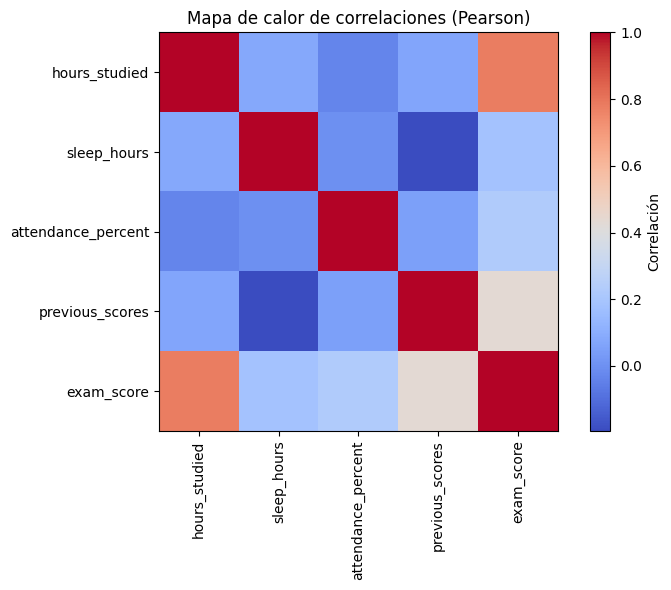

In [8]:
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(method="pearson")
    corr.round(3)
else:
    print("No hay suficientes variables numéricas para correlaciones.")

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.title("Mapa de calor de correlaciones (Pearson)")
plt.colorbar(label="Correlación")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()


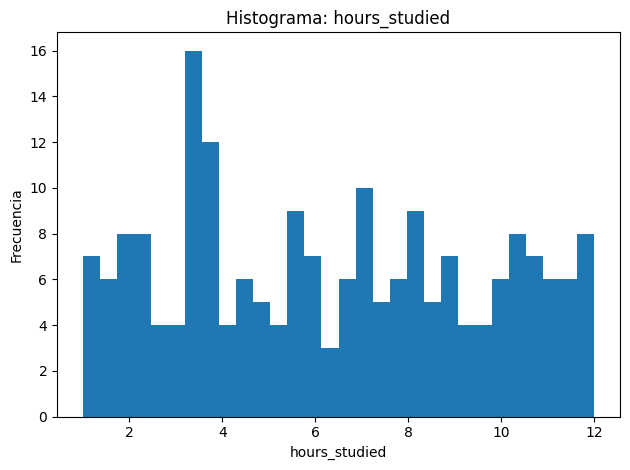

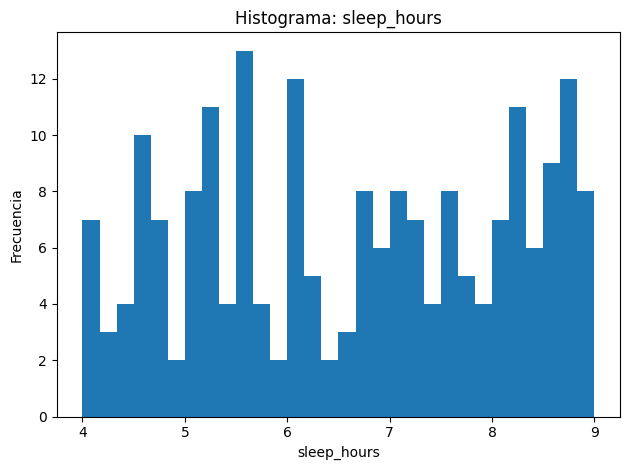

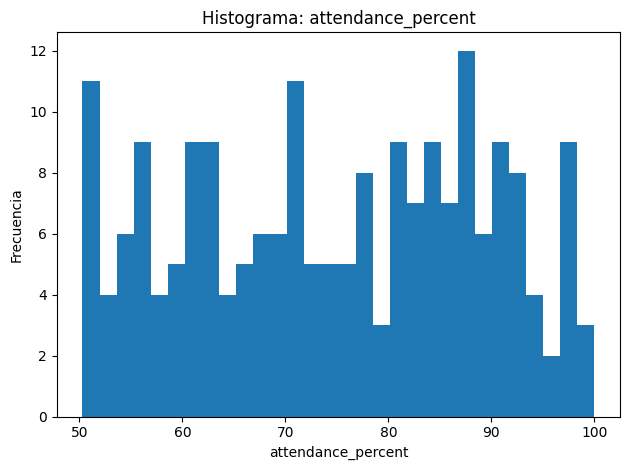

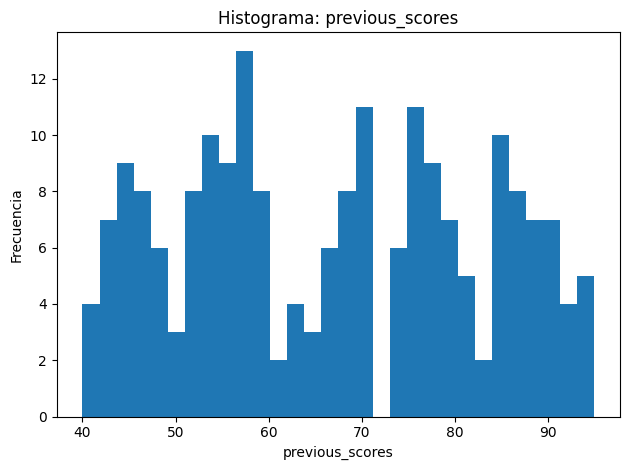

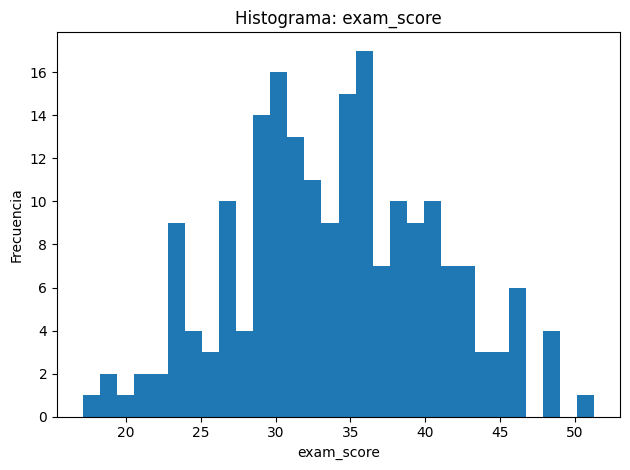

In [9]:
for col in numeric_cols[:6]:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Histograma: {col}")
    plt.xlabel(col); plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

# Análisis histogramas
---

1.   Histograma 1 (hours_studied):
*   Moda: alrededor de las 3,5h, esto sugiere un tiempo de estudia relativamente bajo.
*   Rango: la variable cubre un rango que va desde 1 hasta 12 horas de estudio.
*   Dispersión: la dispersión es bastante alta, por lo que esta variable nos será de bastante utilidad para el modelo.

2.   Histograma 2 (sleep_hours):
*   Moda: en este histograma tenemos varios picos. Podríamos diferenciar entre los grupos con horas de sueño bajas (picos 5.7 y 6.1) y saludables (8.4 y 8.9).
*   Rango: los valores van desde las 4h a las 9h (un rango bastabte amplio teniendo en cuenta que hablamos de horas de sueño).
*   Dispersión: nos encontramos con una alta dispersión (misma implicación que en el histograma 1).

3.   Histograma 3 (attendance_percent):
*   Moda: nuevamente tenemos varios picos: 50%, 71%, 88% y 98%. Podemos concluir que nuestro modelo analiza datos de alumnos con una asistencia media-alta.
*   Dispersión: hay una dispersión alta entre el 50% y el 100%. Presenta una ligera concentración entorno al valor 90%.

3.   Histograma 4(previus_scores):
*   Moda: podemos diferenciar 3 grandes grupos: nota baja (55-60), nota media (70-75) y notas altas (85-90). Presenta una distrubución muy irregular (con muchos picos).
*   Rango: cubre un rango en la puntuación de entre 40 y 95 (sobre 100).
*   Dispersión: muy alta.
3.   Histograma 5(examen_score/Variable Objetivo):
*   Rango: cubre un rango en la puntuación mucho más pequeño que en el caso anterior (entre 18 y 51).
*   Dispersión: muy alta.

En todos los histogramas analizados hemos encontrado pocos valores atípicos y una alta dispersión. Esto favorece la fiabilidad de nuestro modelo.








/tmp/ipython-input-1282227805.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, vert=True, labels=numeric_cols[:8], showfliers=True)


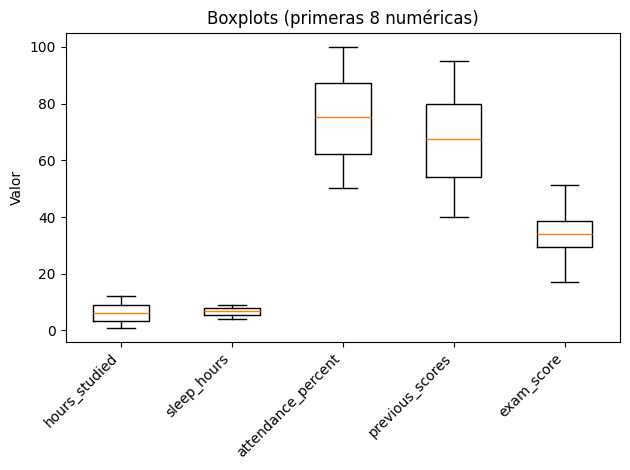

In [10]:
if len(numeric_cols) >= 1:
    plt.figure()
    data = [df[c].dropna().values for c in numeric_cols[:8]]
    plt.boxplot(data, vert=True, labels=numeric_cols[:8], showfliers=True)
    plt.title("Boxplots (primeras 8 numéricas)")
    plt.ylabel("Valor")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Sin numéricas para boxplot.")

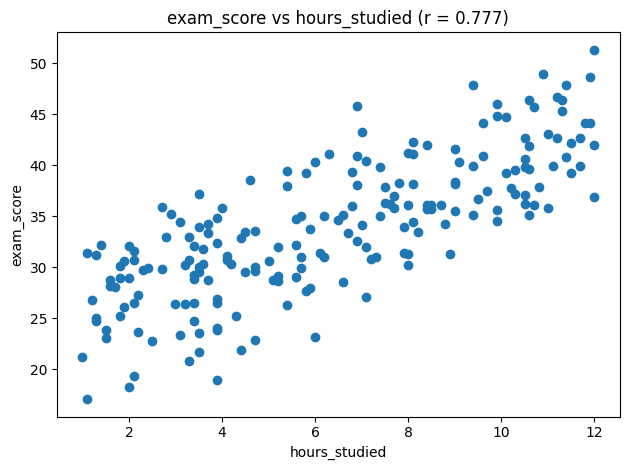

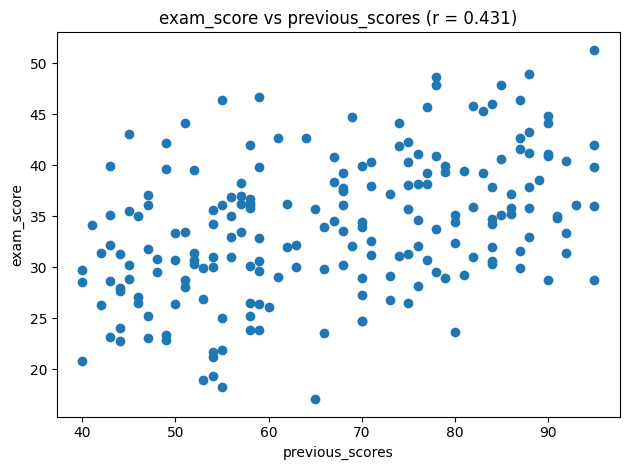

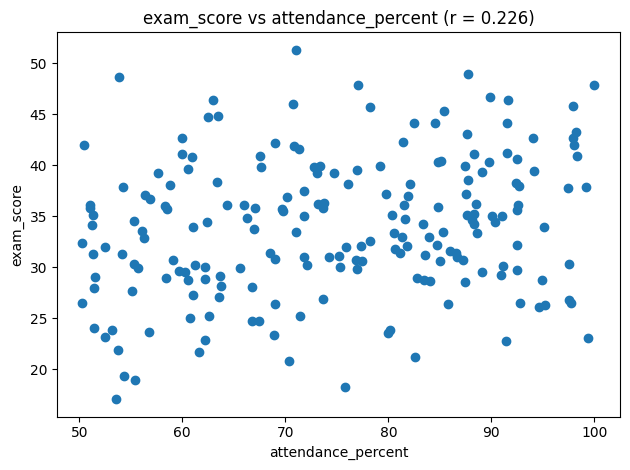

In [11]:
if TARGET in df.columns and pd.api.types.is_numeric_dtype(df[TARGET]) and len(numeric_cols) >= 2:
    abs_corrs = df[numeric_cols].corr(method="pearson")[TARGET].drop(labels=[TARGET]).abs().sort_values(ascending=False)
    for x in list(abs_corrs.index[:3]):
        r = df[[x, TARGET]].corr(method="pearson").iloc[0, 1]
        plt.figure()
        plt.scatter(df[x], df[TARGET])
        plt.title(f"{TARGET} vs {x} (r = {r:.3f})")
        plt.xlabel(x); plt.ylabel(TARGET)
        plt.tight_layout()
        plt.show()
else:
    print("No se pudo trazar dispersión Y vs X (revisa TARGET o tipos numéricos).")